In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("xgboost") is None:
    print("Installing xgboost...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
else:
    print("xgboost is already installed.")

Installing xgboost...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 18.0 MB/s  0:00:00 eta 0:00:01



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [3]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 25.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

pd.options.display.float_format = "{:,.4f}".format
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

BASE_DIR = Path("/Users/tonytony/Final Project")
DATA_PATH = BASE_DIR / "Data" / "Cleaned" / "panel_with_event_dummies_and_extra_drivers.csv"
MAIN_METRICS_PATH = BASE_DIR / "Data" / "Cleaned" / "gdp_main_models_rebuilt_with_lag_metrics.csv"
OUTPUT_DIR = BASE_DIR / "Data" / "Cleaned"

TRAIN_END_YEAR = 2017
TEST_START_YEAR = 2018
TEST_END_YEAR = 2022

print("Base dir:", BASE_DIR)
print("Data path:", DATA_PATH)
print("Output dir:", OUTPUT_DIR)

Base dir: /Users/tonytony/Final Project
Data path: /Users/tonytony/Final Project/Data/Cleaned/panel_with_event_dummies_and_extra_drivers.csv
Output dir: /Users/tonytony/Final Project/Data/Cleaned


In [2]:
def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    nonzero_mask = actual != 0
    if nonzero_mask.any():
        mape = np.mean(
            np.abs((actual[nonzero_mask] - predicted[nonzero_mask]) / actual[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    r2 = r2_score(actual, predicted)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE_pct": mape,
        "R_squared": r2,
    }


def sanitize_feature_names(columns):
    clean_cols = []
    for col in columns:
        clean_col = (
            str(col)
            .replace(" ", "_")
            .replace("&", "and")
            .replace(",", "")
            .replace("(", "")
            .replace(")", "")
            .replace("/", "_")
            .replace("-", "_")
        )
        clean_cols.append(clean_col)
    return clean_cols


def build_prediction_frame(model, X, y_log, meta_df, model_name, family, note):
    pred_df = meta_df.copy()
    pred_df["model"] = model_name
    pred_df["model_family"] = family
    pred_df["model_note"] = note

    pred_df["predicted_log_gdp_next_year"] = model.predict(X)
    pred_df["actual_log_gdp_next_year"] = y_log.values

    pred_df["predicted_gdp_next_year"] = np.exp(pred_df["predicted_log_gdp_next_year"])
    pred_df["actual_gdp_next_year"] = np.exp(pred_df["actual_log_gdp_next_year"])

    pred_df["feature_year"] = pred_df["year"].astype(int)
    pred_df["target_year"] = pred_df["feature_year"] + 1
    pred_df["absolute_error_usd"] = np.abs(
        pred_df["actual_gdp_next_year"] - pred_df["predicted_gdp_next_year"]
    )
    pred_df["absolute_percentage_error_pct"] = (
        pred_df["absolute_error_usd"] / pred_df["actual_gdp_next_year"]
    ) * 100
    pred_df["signed_percentage_error_pct"] = (
        (pred_df["predicted_gdp_next_year"] - pred_df["actual_gdp_next_year"])
        / pred_df["actual_gdp_next_year"]
    ) * 100

    return pred_df


def build_metrics_rows(model_name, family, note, train_pred_df, test_pred_df):
    rows = []

    for split_name, pred_df in [("train", train_pred_df), ("test", test_pred_df)]:
        level_metrics = regression_metrics(
            pred_df["actual_gdp_next_year"],
            pred_df["predicted_gdp_next_year"],
        )
        log_metrics = regression_metrics(
            pred_df["actual_log_gdp_next_year"],
            pred_df["predicted_log_gdp_next_year"],
        )

        rows.append(
            {
                "model": model_name,
                "model_family": family,
                "model_note": note,
                "split": split_name,
                "scale": "level_gdp_usd",
                "n_obs": len(pred_df),
                **level_metrics,
            }
        )
        rows.append(
            {
                "model": model_name,
                "model_family": family,
                "model_note": note,
                "split": split_name,
                "scale": "log_gdp",
                "n_obs": len(pred_df),
                **log_metrics,
            }
        )

    return rows


def build_yearly_summary(pred_df):
    rows = []
    for (model_name, target_year), year_df in pred_df.groupby(["model", "target_year"]):
        rows.append(
            {
                "model": model_name,
                "target_year": int(target_year),
                "n_obs": len(year_df),
                "actual_mean_gdp": year_df["actual_gdp_next_year"].mean(),
                "predicted_mean_gdp": year_df["predicted_gdp_next_year"].mean(),
                "pred_to_actual_ratio": (
                    year_df["predicted_gdp_next_year"].mean()
                    / year_df["actual_gdp_next_year"].mean()
                ),
                "mean_absolute_percentage_error_pct": year_df[
                    "absolute_percentage_error_pct"
                ].mean(),
            }
        )
    return pd.DataFrame(rows).sort_values(["model", "target_year"]).reset_index(drop=True)


def build_bias_summary(pred_df):
    return (
        pred_df.groupby("model", as_index=False)
        .agg(
            n_obs=("actual_gdp_next_year", "size"),
            actual_mean_gdp=("actual_gdp_next_year", "mean"),
            predicted_mean_gdp=("predicted_gdp_next_year", "mean"),
            actual_median_gdp=("actual_gdp_next_year", "median"),
            predicted_median_gdp=("predicted_gdp_next_year", "median"),
            mean_absolute_percentage_error_pct=("absolute_percentage_error_pct", "mean"),
            mean_signed_percentage_error_pct=("signed_percentage_error_pct", "mean"),
            median_signed_percentage_error_pct=("signed_percentage_error_pct", "median"),
        )
        .assign(
            pred_to_actual_mean_ratio=lambda df: (
                df["predicted_mean_gdp"] / df["actual_mean_gdp"]
            )
        )
    )

In [3]:
model_cols = [
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "gdp_per_capita_usd",
    "log_gdp_per_capita",
    "population_total",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "target_log_gdp_next_year",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
    "covid_shock_2020",
    "covid_rebound_2021",
    "ukraine_energy_shock_2022_2024",
    "high_global_rates_2023_2024",
    "asia_crisis_exposed_9798",
    "energy_shock_exposed_2022_2024",
]

panel_df = pd.read_csv(DATA_PATH, usecols=model_cols).copy()

numeric_cols = [
    "year",
    "gdp_per_capita_usd",
    "log_gdp_per_capita",
    "population_total",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "target_log_gdp_next_year",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
    "covid_shock_2020",
    "covid_rebound_2021",
    "ukraine_energy_shock_2022_2024",
    "high_global_rates_2023_2024",
    "asia_crisis_exposed_9798",
    "energy_shock_exposed_2022_2024",
]

for col in numeric_cols:
    panel_df[col] = pd.to_numeric(panel_df[col], errors="coerce")

model_df = panel_df.dropna().copy()
model_df["year"] = model_df["year"].astype(int)
model_df["country_name"] = model_df["country_name"].astype(str)
model_df["country_code"] = model_df["country_code"].astype(str)
model_df["wb_region"] = model_df["wb_region"].astype(str)
model_df["year_trend"] = model_df["year"] - model_df["year"].min()

print("Model sample shape:", model_df.shape)
print("Countries:", model_df["country_code"].nunique())
print("Regions:", model_df["wb_region"].nunique())
print("Feature-year range:", int(model_df["year"].min()), "-", int(model_df["year"].max()))
print("Target-year range:", int((model_df["year"] + 1).min()), "-", int((model_df["year"] + 1).max()))

model_df.head()

Model sample shape: (4722, 22)
Countries: 177
Regions: 7
Feature-year range: 1991 - 2022
Target-year range: 1992 - 2023


,country_name,country_code,wb_region,year,gdp_per_capita_usd,life_expectancy_years,population_total,log_gdp_per_capita,log_population_total,target_log_gdp_next_year,...,covid_shock_2020,covid_rebound_2021,ukraine_energy_shock_2022_2024,high_global_rates_2023_2024,asia_crisis_exposed_9798,energy_shock_exposed_2022_2024,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,year_trend
43,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2005,254.1842,58.2470,"24,404,567.0000",5.5381,17.0103,5.6139,...,0,0,0,0,0,0,12.6863,7.8780,1.2241,14
44,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2006,274.2186,58.5530,"25,424,094.0000",5.6139,17.0512,5.9302,...,0,0,0,0,0,0,6.7846,7.8970,2.1071,15
45,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2007,376.2232,58.9560,"25,909,852.0000",5.9302,17.0701,5.9447,...,0,0,0,0,0,0,8.6806,7.8410,1.9000,16
46,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2008,381.7332,59.7080,"26,482,622.0000",5.9447,17.0920,6.1138,...,0,0,0,0,0,0,26.4187,7.8790,1.8400,17
47,Afghanistan,AFG,"Middle East, North Africa, Afghanistan & Pakistan",2009,452.0537,60.2480,"27,466,101.0000",6.1138,17.1285,6.3290,...,0,0,0,0,0,0,-2.8285,7.8080,3.5500,18


In [4]:
feature_cols = [
    "log_gdp_per_capita",
    "log_population_total",
    "life_expectancy_years",
    "inflation_pct_clean",
    "unemployment_pct_clean",
    "internet_users_pct_clean",
    "asian_financial_crisis_9798",
    "global_financial_crisis_0809",
    "covid_shock_2020",
    "covid_rebound_2021",
    "ukraine_energy_shock_2022_2024",
    "high_global_rates_2023_2024",
    "asia_crisis_exposed_9798",
    "energy_shock_exposed_2022_2024",
    "year_trend",
    "wb_region",
]

target_col = "target_log_gdp_next_year"

X_all = pd.get_dummies(
    model_df[feature_cols],
    columns=["wb_region"],
    drop_first=False,
)

X_all.columns = sanitize_feature_names(X_all.columns)
y_all = model_df[target_col].copy()

meta_cols = [
    "country_name",
    "country_code",
    "wb_region",
    "year",
    "gdp_per_capita_usd",
]
meta_df = model_df[meta_cols].copy()

train_mask = model_df["year"] <= TRAIN_END_YEAR
test_mask = (model_df["year"] >= TEST_START_YEAR) & (model_df["year"] <= TEST_END_YEAR)

X_train = X_all.loc[train_mask].copy()
X_test = X_all.loc[test_mask].copy()

y_train = y_all.loc[train_mask].copy()
y_test = y_all.loc[test_mask].copy()

meta_train = meta_df.loc[train_mask].copy()
meta_test = meta_df.loc[test_mask].copy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Test target years:", int((meta_test['year'] + 1).min()), "-", int((meta_test['year'] + 1).max()))

X_train.head()

X_train shape: (3909, 22)
X_test shape: (813, 22)
Train rows: 3909
Test rows: 813
Test target years: 2019 - 2023


,log_gdp_per_capita,log_population_total,life_expectancy_years,inflation_pct_clean,unemployment_pct_clean,internet_users_pct_clean,asian_financial_crisis_9798,global_financial_crisis_0809,covid_shock_2020,covid_rebound_2021,...,asia_crisis_exposed_9798,energy_shock_exposed_2022_2024,year_trend,wb_region_East_Asia_and_Pacific,wb_region_Europe_and_Central_Asia,wb_region_Latin_America_and_Caribbean_,wb_region_Middle_East_North_Africa_Afghanistan_and_Pakistan,wb_region_North_America,wb_region_South_Asia,wb_region_Sub_Saharan_Africa_
43,5.5381,17.0103,58.2470,12.6863,7.8780,1.2241,0,0,0,0,...,0,0,14,False,False,False,True,False,False,False
44,5.6139,17.0512,58.5530,6.7846,7.8970,2.1071,0,0,0,0,...,0,0,15,False,False,False,True,False,False,False
45,5.9302,17.0701,58.9560,8.6806,7.8410,1.9000,0,0,0,0,...,0,0,16,False,False,False,True,False,False,False
46,5.9447,17.0920,59.7080,26.4187,7.8790,1.8400,0,1,0,0,...,0,0,17,False,False,False,True,False,False,False
47,6.1138,17.1285,60.2480,-2.8285,7.8080,3.5500,0,1,0,0,...,0,0,18,False,False,False,True,False,False,False


In [5]:
rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=14,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
)

xgb_model = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

model_library = {
    "ML Benchmark - Random Forest": {
        "model": rf_model,
        "family": "Tree-based ML",
        "note": "Random Forest benchmark on the full dynamic feature set.",
    },
    "ML Benchmark - XGBoost": {
        "model": xgb_model,
        "family": "Tree-based ML",
        "note": "XGBoost benchmark on the full dynamic feature set.",
    },
}

fitted_models = {}
metrics_rows = []
train_prediction_tables = []
test_prediction_tables = []

for model_name, spec in model_library.items():
    model = spec["model"]
    family = spec["family"]
    note = spec["note"]

    model.fit(X_train, y_train)
    fitted_models[model_name] = model

    train_pred_df = build_prediction_frame(
        model=model,
        X=X_train,
        y_log=y_train,
        meta_df=meta_train,
        model_name=model_name,
        family=family,
        note=note,
    )
    test_pred_df = build_prediction_frame(
        model=model,
        X=X_test,
        y_log=y_test,
        meta_df=meta_test,
        model_name=model_name,
        family=family,
        note=note,
    )

    metrics_rows.extend(
        build_metrics_rows(
            model_name=model_name,
            family=family,
            note=note,
            train_pred_df=train_pred_df,
            test_pred_df=test_pred_df,
        )
    )

    train_prediction_tables.append(train_pred_df)
    test_prediction_tables.append(test_pred_df)

    print(f"Finished: {model_name}")

Finished: ML Benchmark - Random Forest
Finished: ML Benchmark - XGBoost


In [6]:
ml_metrics_df = pd.DataFrame(metrics_rows).round(4)
ml_train_predictions_df = pd.concat(train_prediction_tables, ignore_index=True).round(4)
ml_test_predictions_df = pd.concat(test_prediction_tables, ignore_index=True).round(4)

ml_yearly_summary_df = build_yearly_summary(ml_test_predictions_df).round(4)
ml_bias_summary_df = build_bias_summary(ml_test_predictions_df).round(4)

print("ML metrics shape:", ml_metrics_df.shape)
print("ML test predictions shape:", ml_test_predictions_df.shape)

ml_metrics_df

ML metrics shape: (8, 10)
ML test predictions shape: (1626, 17)


,model,model_family,model_note,split,scale,n_obs,MAE,RMSE,MAPE_pct,R_squared
0,ML Benchmark - Random Forest,Tree-based ML,Random Forest benchmark on the full dynamic fe...,train,level_gdp_usd,3909,480.8570,"1,120.6075",4.7486,0.9958
1,ML Benchmark - Random Forest,Tree-based ML,Random Forest benchmark on the full dynamic fe...,train,log_gdp,3909,0.0470,0.0751,0.5998,0.9977
2,ML Benchmark - Random Forest,Tree-based ML,Random Forest benchmark on the full dynamic fe...,test,level_gdp_usd,813,"1,634.2193","3,862.8804",9.5218,0.9711
3,ML Benchmark - Random Forest,Tree-based ML,Random Forest benchmark on the full dynamic fe...,test,log_gdp,813,0.0942,0.1294,1.0784,0.9916
4,ML Benchmark - XGBoost,Tree-based ML,XGBoost benchmark on the full dynamic feature ...,train,level_gdp_usd,3909,544.4684,"1,170.1226",5.5628,0.9954
5,ML Benchmark - XGBoost,Tree-based ML,XGBoost benchmark on the full dynamic feature ...,train,log_gdp,3909,0.0553,0.0785,0.7047,0.9975
6,ML Benchmark - XGBoost,Tree-based ML,XGBoost benchmark on the full dynamic feature ...,test,level_gdp_usd,813,"1,684.8381","3,851.0540",10.1118,0.9712
7,ML Benchmark - XGBoost,Tree-based ML,XGBoost benchmark on the full dynamic feature ...,test,log_gdp,813,0.0981,0.1327,1.1269,0.9912


In [7]:
main_metrics_df = pd.read_csv(MAIN_METRICS_PATH)

main_test_level_df = main_metrics_df[
    (main_metrics_df["split"].astype(str).str.lower() == "test")
    & (main_metrics_df["scale"].astype(str).str.lower() == "level_gdp_usd")
].copy()

ml_test_level_df = ml_metrics_df[
    (ml_metrics_df["split"].astype(str).str.lower() == "test")
    & (ml_metrics_df["scale"].astype(str).str.lower() == "level_gdp_usd")
].copy()

compare_df = pd.concat(
    [
        main_test_level_df[["model", "model_family", "split", "scale", "n_obs", "MAE", "RMSE", "MAPE_pct", "R_squared"]],
        ml_test_level_df[["model", "model_family", "split", "scale", "n_obs", "MAE", "RMSE", "MAPE_pct", "R_squared"]],
    ],
    ignore_index=True,
)

compare_df = compare_df.sort_values(["RMSE", "MAPE_pct", "MAE"]).reset_index(drop=True)
compare_df["rank_by_rmse"] = np.arange(1, len(compare_df) + 1)

compare_df

,model,model_family,split,scale,n_obs,MAE,RMSE,MAPE_pct,R_squared,rank_by_rmse
0,Model 3 - Full Dynamic,Dynamic pooled OLS,test,level_gdp_usd,813,"1,468.1942","3,472.9950",8.8964,0.9766,1
1,Model 1 - Baseline Dynamic,Dynamic pooled OLS,test,level_gdp_usd,813,"1,498.1181","3,477.1503",9.1617,0.9766,2
2,Model 2 - Extended Dynamic,Dynamic pooled OLS,test,level_gdp_usd,813,"1,485.0940","3,482.8558",9.0518,0.9765,3
3,ML Benchmark - XGBoost,Tree-based ML,test,level_gdp_usd,813,"1,684.8381","3,851.0540",10.1118,0.9712,4
4,ML Benchmark - Random Forest,Tree-based ML,test,level_gdp_usd,813,"1,634.2193","3,862.8804",9.5218,0.9711,5


/var/folders/7n/3748sj1972d585qn1zk46ln00000gn/T/ipykernel_51070/3837835417.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


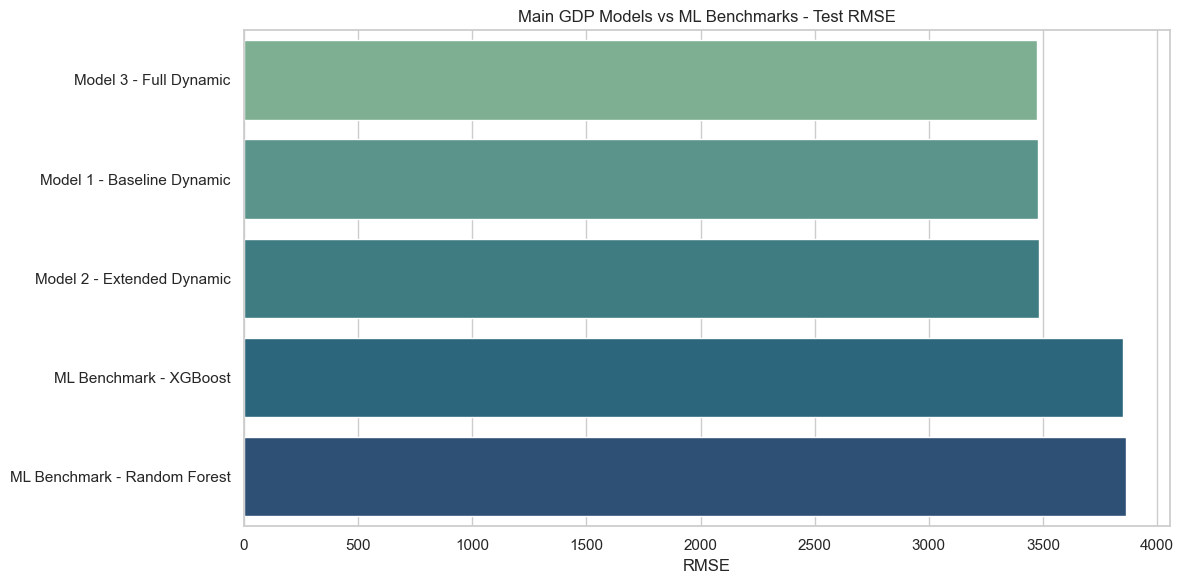

/var/folders/7n/3748sj1972d585qn1zk46ln00000gn/T/ipykernel_51070/3837835417.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


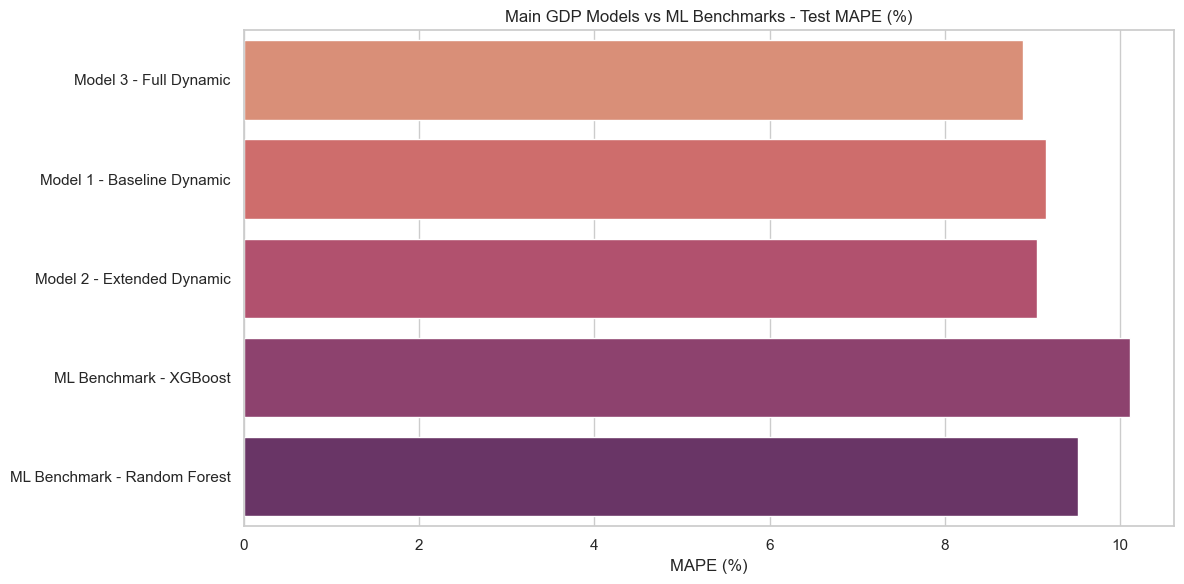

In [8]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=compare_df,
    x="RMSE",
    y="model",
    palette="crest",
)
plt.title("Main GDP Models vs ML Benchmarks - Test RMSE")
plt.xlabel("RMSE")
plt.ylabel("")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=compare_df,
    x="MAPE_pct",
    y="model",
    palette="flare",
)
plt.title("Main GDP Models vs ML Benchmarks - Test MAPE (%)")
plt.xlabel("MAPE (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [9]:
ml_yearly_summary_df

,model,target_year,n_obs,actual_mean_gdp,predicted_mean_gdp,pred_to_actual_ratio,mean_absolute_percentage_error_pct
0,ML Benchmark - Random Forest,2019,166,"15,698.9605","16,240.0058",1.0345,5.7616
1,ML Benchmark - Random Forest,2020,166,"14,549.3612","16,152.7886",1.1102,13.7316
2,ML Benchmark - Random Forest,2021,162,"17,155.0981","15,014.3741",0.8752,10.5625
3,ML Benchmark - Random Forest,2022,160,"18,048.6179","17,197.6172",0.9528,8.7741
4,ML Benchmark - Random Forest,2023,159,"18,914.0876","17,975.8164",0.9504,8.7447
5,ML Benchmark - XGBoost,2019,166,"15,698.9605","16,731.9857",1.0658,7.2462
6,ML Benchmark - XGBoost,2020,166,"14,549.3612","16,528.6768",1.1360,16.2145
7,ML Benchmark - XGBoost,2021,162,"17,155.0981","15,477.7411",0.9022,9.1998
8,ML Benchmark - XGBoost,2022,160,"18,048.6179","17,541.9963",0.9719,9.3764
9,ML Benchmark - XGBoost,2023,159,"18,914.0876","18,010.3721",0.9522,8.4014


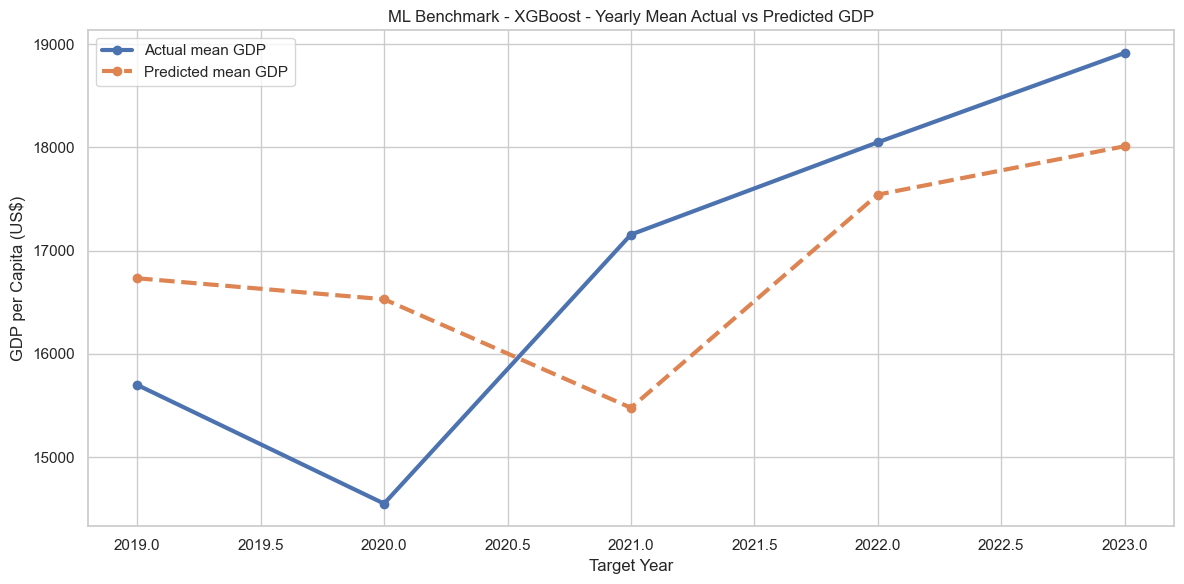

In [10]:
selected_model_name = "ML Benchmark - XGBoost"

plot_df = ml_yearly_summary_df[ml_yearly_summary_df["model"] == selected_model_name].copy()

plt.figure(figsize=(12, 6))
plt.plot(
    plot_df["target_year"],
    plot_df["actual_mean_gdp"],
    marker="o",
    linewidth=3,
    label="Actual mean GDP",
)
plt.plot(
    plot_df["target_year"],
    plot_df["predicted_mean_gdp"],
    marker="o",
    linewidth=3,
    linestyle="--",
    label="Predicted mean GDP",
)
plt.title(f"{selected_model_name} - Yearly Mean Actual vs Predicted GDP")
plt.xlabel("Target Year")
plt.ylabel("GDP per Capita (US$)")
plt.legend()
plt.tight_layout()
plt.show()

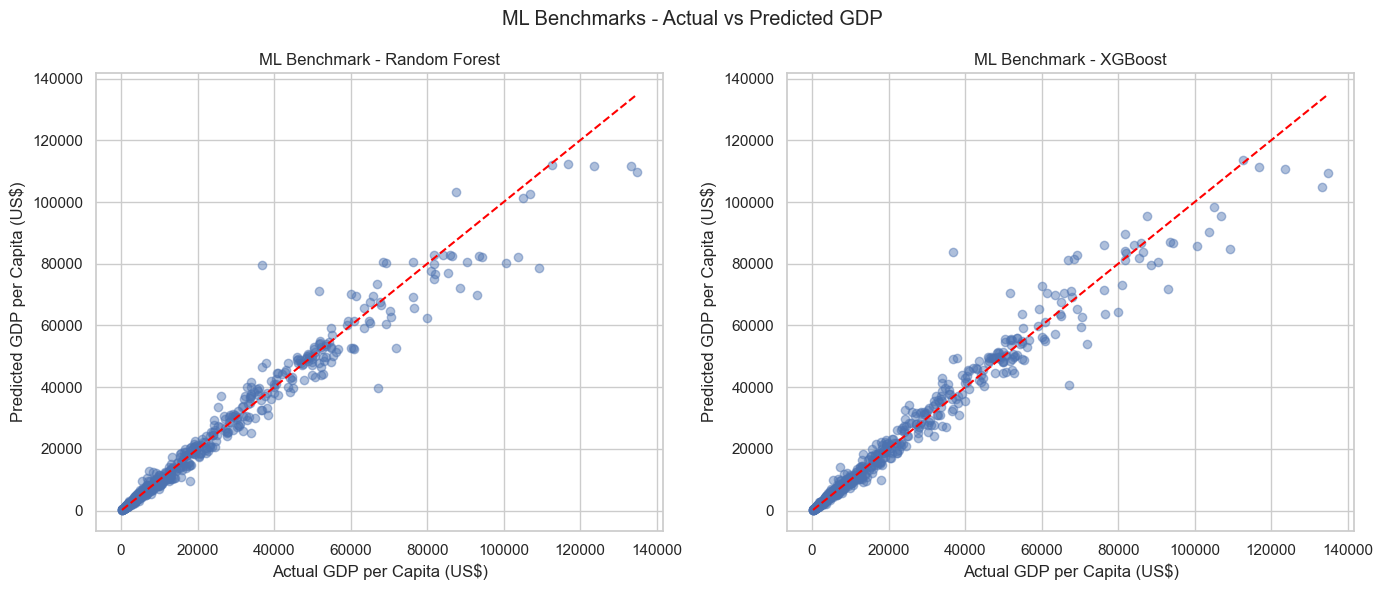

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model_name in zip(axes, fitted_models.keys()):
    scatter_df = ml_test_predictions_df[ml_test_predictions_df["model"] == model_name].copy()

    ax.scatter(
        scatter_df["actual_gdp_next_year"],
        scatter_df["predicted_gdp_next_year"],
        alpha=0.45,
    )

    min_val = min(
        scatter_df["actual_gdp_next_year"].min(),
        scatter_df["predicted_gdp_next_year"].min(),
    )
    max_val = max(
        scatter_df["actual_gdp_next_year"].max(),
        scatter_df["predicted_gdp_next_year"].max(),
    )

    ax.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
    ax.set_title(model_name)
    ax.set_xlabel("Actual GDP per Capita (US$)")
    ax.set_ylabel("Predicted GDP per Capita (US$)")

plt.suptitle("ML Benchmarks - Actual vs Predicted GDP")
plt.tight_layout()
plt.show()

In [12]:
feature_importance_tables = []

for model_name, model in fitted_models.items():
    importances = pd.DataFrame(
        {
            "model": model_name,
            "feature": X_train.columns,
            "importance": model.feature_importances_,
        }
    ).sort_values("importance", ascending=False)

    feature_importance_tables.append(importances)

feature_importance_df = pd.concat(feature_importance_tables, ignore_index=True)
feature_importance_df.head(20)

,model,feature,importance
0,ML Benchmark - Random Forest,log_gdp_per_capita,0.9960
1,ML Benchmark - Random Forest,year_trend,0.0008
2,ML Benchmark - Random Forest,inflation_pct_clean,0.0007
3,ML Benchmark - Random Forest,life_expectancy_years,0.0007
4,ML Benchmark - Random Forest,internet_users_pct_clean,0.0005
5,ML Benchmark - Random Forest,unemployment_pct_clean,0.0005
6,ML Benchmark - Random Forest,log_population_total,0.0005
7,ML Benchmark - Random Forest,asian_financial_crisis_9798,0.0001
8,ML Benchmark - Random Forest,global_financial_crisis_0809,0.0001
9,ML Benchmark - Random Forest,wb_region_Europe_and_Central_Asia,0.0001


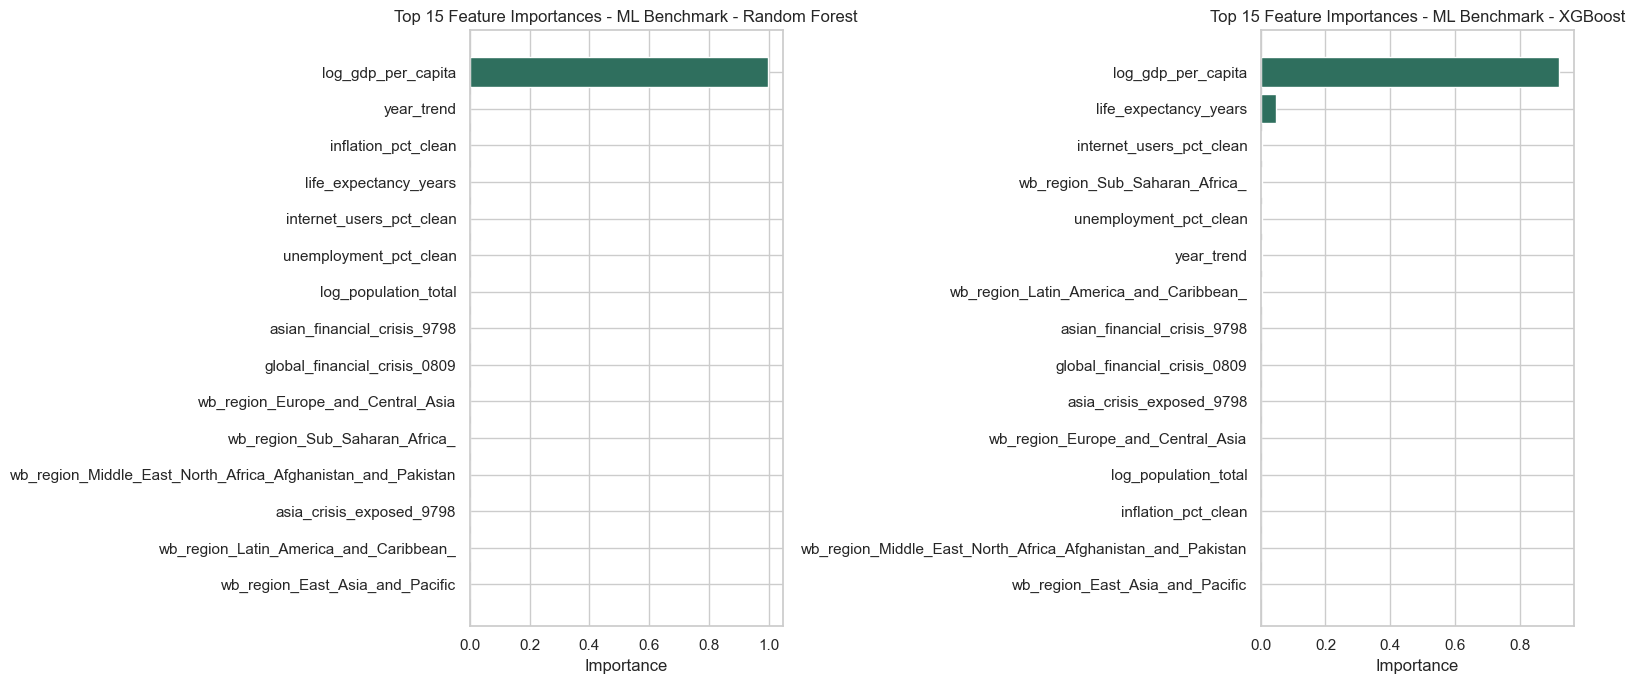

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model_name in zip(axes, fitted_models.keys()):
    top_df = (
        feature_importance_df[feature_importance_df["model"] == model_name]
        .head(15)
        .sort_values("importance", ascending=True)
    )

    ax.barh(top_df["feature"], top_df["importance"], color="#2f6f5e")
    ax.set_title(f"Top 15 Feature Importances - {model_name}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [14]:
ml_bias_summary_df

,model,n_obs,actual_mean_gdp,predicted_mean_gdp,actual_median_gdp,predicted_median_gdp,mean_absolute_percentage_error_pct,mean_signed_percentage_error_pct,median_signed_percentage_error_pct,pred_to_actual_mean_ratio
0,ML Benchmark - Random Forest,813,"16,845.5917","16,505.9115","6,542.8558","6,354.0933",9.5218,0.7830,0.3528,0.9798
1,ML Benchmark - XGBoost,813,"16,845.5917","16,849.9786","6,542.8558","6,616.0991",10.1118,3.0142,2.2784,1.0003
